# Predictive Maintenance 

## MLE - Bayes theorem

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
from scipy.stats import randint
from scipy.stats import norm

import os

* Predictive Maintenance data file path

In [3]:
homedir=os.environ['HOME'] + '/'
datapath=homedir + 'datasets/'
predmaint="predictive_maintenance.csv"

* Create Pandas data frame

In [4]:
pmfile=f"{datapath}{predmaint}"
pm_data = pd.read_csv(pmfile)

* Column data extraction for specific parameters

In [5]:
# Extract specific columns
air_temp = pm_data['Air temperature [K]'].values
pro_temp = pm_data['Process temperature [K]'].values
rot_speed = pm_data['Rotational speed [rpm]'].values

# Display first few rows
print(air_temp[:10])
print(pro_temp[:10])
print(rot_speed[:10])

[298.1 298.2 298.1 298.2 298.2 298.1 298.1 298.1 298.3 298.5]
[308.6 308.7 308.5 308.6 308.7 308.6 308.6 308.6 308.7 309. ]
[1551 1408 1498 1433 1408 1425 1558 1527 1667 1741]


* Histogram data for the parameters

Text(0.5, 1.0, 'Histograms of Sensor Data')

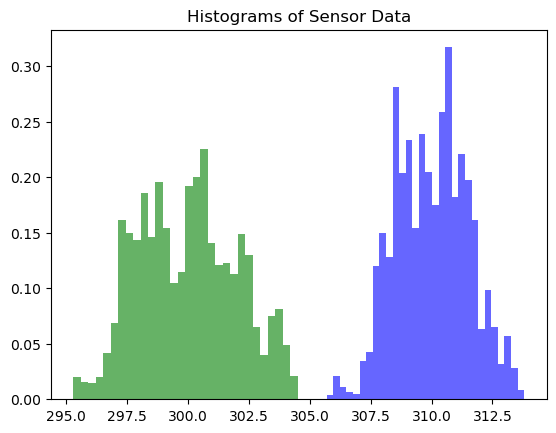

In [6]:
plt.hist(air_temp, bins=30, density=True, alpha=0.6, color='g')
plt.hist(pro_temp, bins=30, density=True, alpha=0.6, color='b')
#plt.hist(rot_speed, bins=30, density=True, alpha=0.6, color='b')
plt.title('Histograms of Sensor Data')


### Two classes - Target = 0, Target = 1

In [7]:
c0 = pm_data[pm_data['Target'] == 0]
c1 = pm_data[pm_data['Target'] == 1]

### Get data corresponding to features
  - Air Temperature
  - Process Temperature
  - Rotational Speed

### feature data for class c0

In [ ]:
c0_airtemp = c0['Air temperature [K]'].values
c0_proctemp = c0['Process temperature [K]'].values
c0_rotspeed = c0['Rotational speed [rpm]'].values

array([298.1, 298.2, 298.1, ..., 299. , 299. , 299. ], shape=(9661,))

### feature data for class c1

In [16]:
c1_airtemp = c1['Air temperature [K]'].values
c1_proctemp = c1['Process temperature [K]'].values
c1_rotspeed = c1['Rotational speed [rpm]'].values

### Define a function which 
* Fit `Gaussian` function to the feature
* Arguments to the function
  - feature array corresponding to the class (c0, c1)
  - Labels used for plots

In [13]:
def gaussian_pdf(x, mu, sigma):
    return (1/(np.sqrt(2*np.pi)*sigma)) * np.exp(-((x-mu)**2)/(2*sigma**2))

In [10]:
def compute_gaussian_pdf(ftr_data):
    ftr_data_mu = np.mean(ftr_data)
    ftr_data_sigma = np.std(ftr_data)
    x = np.linspace(min(ftr_data), max(ftr_data), 1000)

    pdf_ftr = gaussian_pdf(x, ftr_data_mu, ftr_data_sigma)
    
    return x, pdf_ftr

In [18]:
def plot_histograms(ftr_data, title_str, xlabel_str, ylable_str, color='tab:blue'):
    x_ftr, pdf_ftr = compute_gaussian_pdf(ftr_data)
    plt.figure()
    plt.hist(ftr_data, bins=40, density=True, alpha=0.4, color=color)
    plt.plot(x_ftr, pdf_ftr)
    plt.title(title_str)
    plt.xlabel(xlabel_str)
    plt.ylabel(ylable_str)
    plt.show()

### For class c0, fit `Gaussian` function to `Air Temperature`

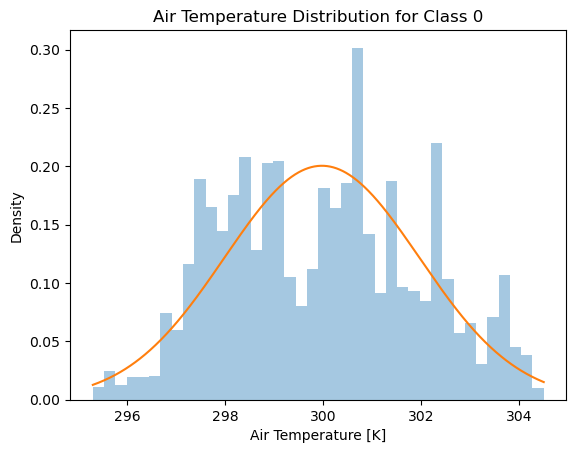

In [14]:
plot_histograms(c0_airtemp, 'Air Temperature Distribution for Class 0', 'Air Temperature [K]', 'Density')

### For class c1, fit `Gaussian` function to `Air Temperature`

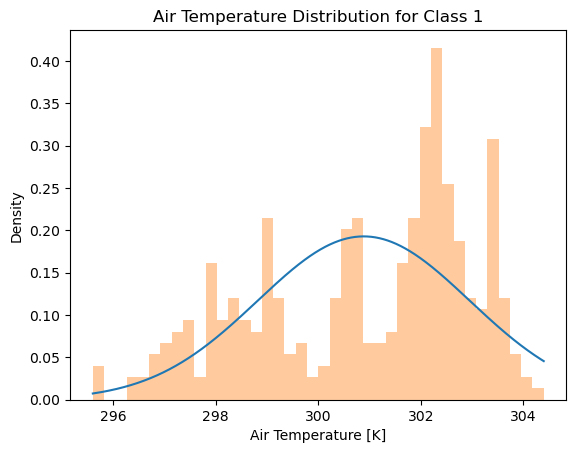

In [19]:
plot_histograms(c1_airtemp, 'Air Temperature Distribution for Class 1', 'Air Temperature [K]', 'Density', "tab:orange")

### For class c0, fit `Gaussian` function to `Process Temperature`

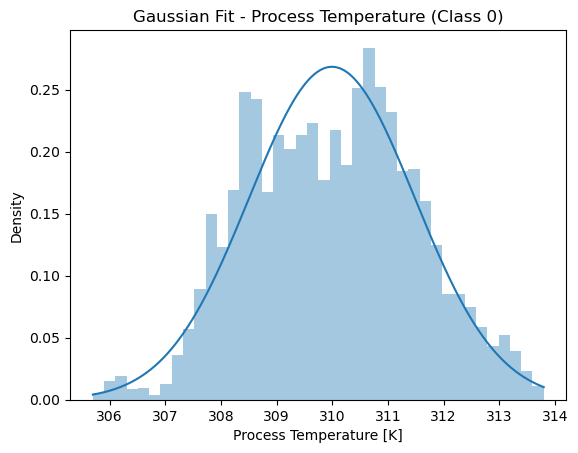

In [20]:
plot_histograms(c0_proctemp, 'Gaussian Fit - Process Temperature (Class 0)', 'Process Temperature [K]', 'Density')

### For class c1, fit `Gaussian` function to `Process Temperature`

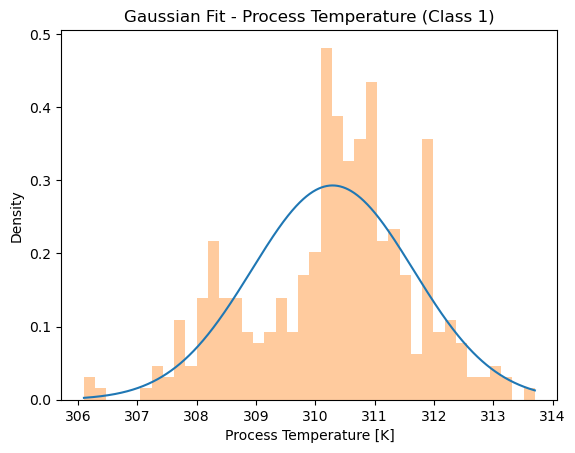

In [21]:
plot_histograms(c1_proctemp, 'Gaussian Fit - Process Temperature (Class 1)', 
                'Process Temperature [K]', 'Density', color='tab:orange')

### For class c0, fit `Gaussian` function to `Rotational Speed`

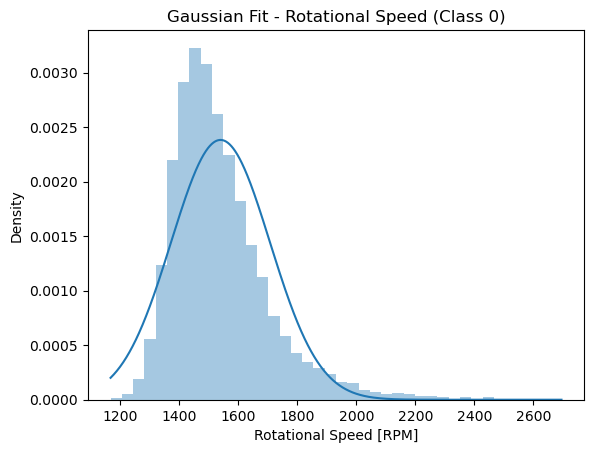

In [22]:
plot_histograms(c0_rotspeed, 'Gaussian Fit - Rotational Speed (Class 0)', 'Rotational Speed [RPM]', 'Density')

### For class c1, fit `Gaussian` function to `Rotational Speed`

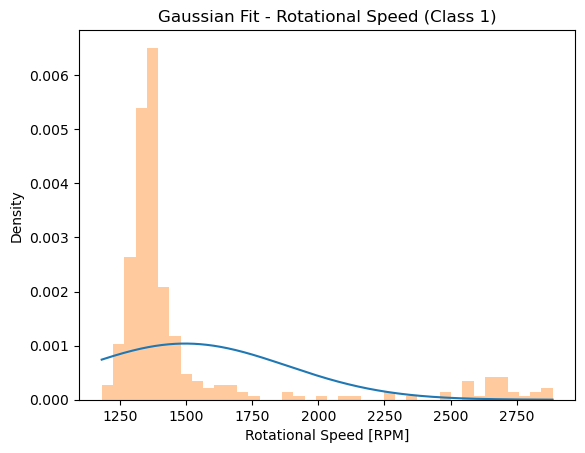

In [23]:
plot_histograms(c1_rotspeed, 'Gaussian Fit - Rotational Speed (Class 1)', 
                'Rotational Speed [RPM]', 'Density', color='tab:orange')